# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Aryo Dwi Haryanto
- Email: aryodwi122@gmail.com
- Id Dicoding:aryo_dwi_h

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# Import library untuk manipulasi data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Menyiapkan data yang akan diguankan

In [2]:
# Load dataset
df = pd.read_csv('data.csv', sep=';')

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [3]:
print("Informasi Dataset:")
df.info()
print("\n-----------------------------------\n")

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                       

In [4]:
print("Pengecekan Missing Value:")
print(df.isnull().sum())
print("\n-----------------------------------\n")

Pengecekan Missing Value:
Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment       

**Insight:**
* ada 36 data
* Tidak ada missing value

In [5]:
duplicate_count = df.duplicated().sum()
print("Jumlah duplikasi: ", duplicate_count)

Jumlah duplikasi:  0


**Insight:**
* tidak ada data yang duplikasi

In [6]:
# Melihat distribusi target
status_counts = df['Status'].value_counts()
print(status_counts)

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


**Insight:**
* sebanyak 2209 data graduate
* sebanyak 1421 data dropout
* sebanyak 794 data enrolled

**Insight:**

# Exploratory Data Analysis (EDA)

In [7]:
# Memisahkan kolom numerikal dan kategorikal untuk keperluan EDA
# Beberapa kolom di dataset ini sebenarnya kategorikal tapi di-encode sebagai angka (misal: Marital_status)
# Namun untuk kemudahan awal, kita pisahkan berdasarkan tipe data riil dan float/integer yang kontinu
numeric_cols = ['Admission_grade', 'Previous_qualification_grade', 'Age_at_enrollment',
                'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
                'Unemployment_rate', 'Inflation_rate', 'GDP']

categorical_cols = [col for col in df.columns if col not in numeric_cols and col != 'Status']

/tmp/ipykernel_8171/30862716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='Set2')


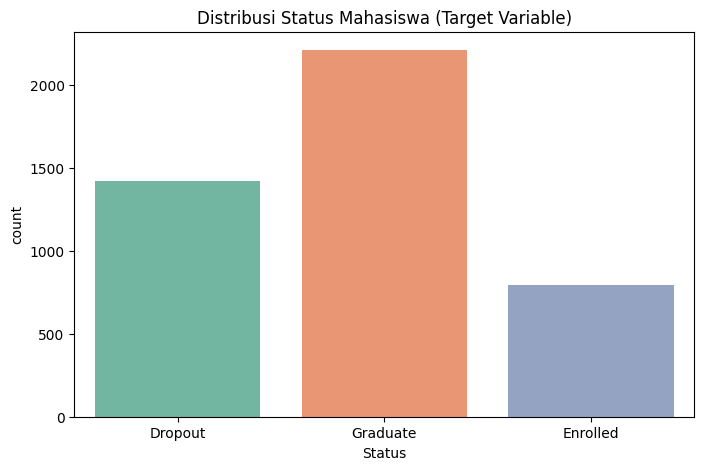

In [8]:
# --- EDA KATEGORIKAL (Univariate) ---
# Distribusi Variabel Target (Status)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Distribusi Status Mahasiswa (Target Variable)')
plt.show()

**Insight:**
1. Dominasi Lulusan (Graduate)
Kelompok mahasiswa dengan status Graduate merupakan jumlah terbanyak dalam dataset ini, mencapai lebih dari 2.200 orang.

2. Angka Dropout yang Cukup Signifikan
Status Dropout berada di posisi kedua dengan jumlah sekitar 1.400 orang. Meskipun jumlahnya di bawah angka kelulusan, angka ini tergolong cukup tinggi (lebih dari setengah jumlah lulusan).

3. Proporsi Mahasiswa Aktif (Enrolled)
Jumlah mahasiswa dengan status Enrolled (masih terdaftar/aktif) adalah yang paling sedikit, yakni di bawah 800 orang.

4. Ketidakseimbangan Data (Class Imbalance)
Terdapat perbedaan jumlah yang cukup mencolok antar kategori (misalnya, jumlah Graduate hampir 3x lipat dari Enrolled).

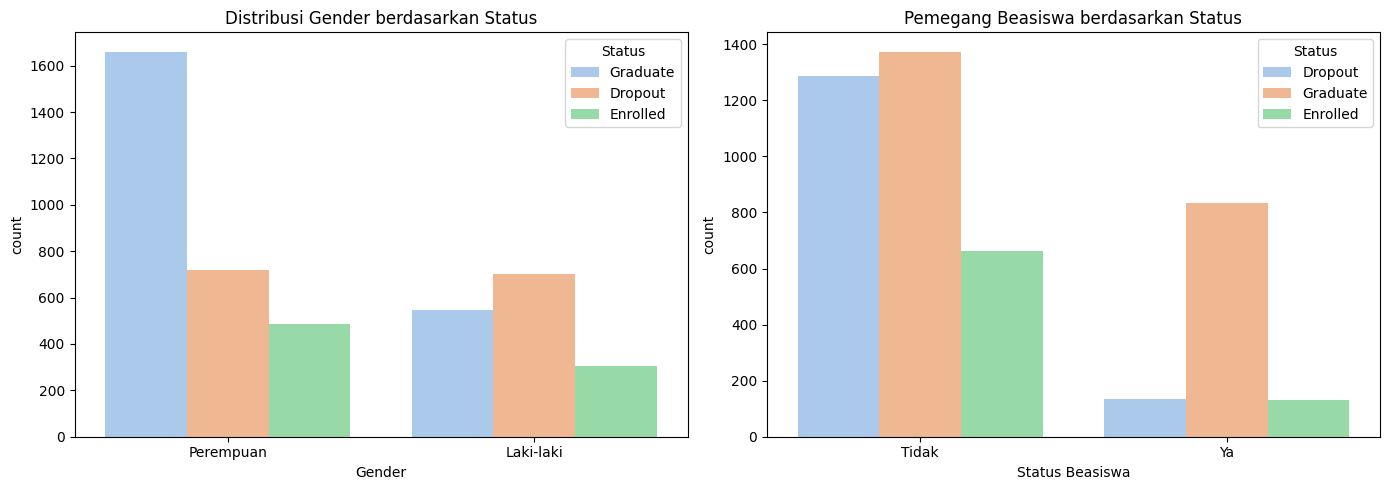

In [9]:
# Distribusi beberapa variabel kategorikal penting (Gender & Beasiswa)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Gender
sns.countplot(data=df, x='Gender', hue='Status', ax=axes[0], palette='pastel')
axes[0].set_title('Distribusi Gender berdasarkan Status')
axes[0].set_xlabel('Gender')
# Mengubah label 0 dan 1 menjadi Perempuan dan Laki-laki
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Perempuan', 'Laki-laki'])

# Plot 2: Beasiswa
sns.countplot(data=df, x='Scholarship_holder', hue='Status', ax=axes[1], palette='pastel')
axes[1].set_title('Pemegang Beasiswa berdasarkan Status')
axes[1].set_xlabel('Status Beasiswa')
# Mengubah label 0 dan 1 menjadi Tidak dan Ya
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Tidak', 'Ya'])

plt.tight_layout()
plt.show()

**Insight:**

1. Distribusi Gender berdasarkan Status

* Gender perempuan mendominasi kategori Graduate
Jumlah Graduate pada Perempuan jauh lebih tinggi dibanding Laki-laki. Ini menunjukkan perempuan memiliki tingkat kelulusan lebih baik.

* Laki-laki memiliki jumlah Dropout yang sedikit lebih tinggi dibanding Graduate.
Mengindikasikan risiko dropout lebih besar pada laki-laki.

* Enrolled relatif lebih sedikit di kedua gender
* Status Enrolled paling rendah di kedua gender.
Artinya sebagian besar mahasiswa sudah berada di tahap akhir (lulus atau dropout).

* Kesenjangan signifikan antar gender
Total mahasiswa perempuan lebih banyak dibanding Laki-laki.
Bisa mengindikasikan ketidakseimbangan populasi mahasiswa.

2. Pengaruh Beasiswa terhadap Status

* Mahasiswa tanpa beasiswa perempuan mendominasi semua status
Mayoritas mahasiswa tidak menerima beasiswa.

* Jumlah Graduate pada penerima beasiswa laki-laki jauh lebih tinggi dibanding Dropout.Mengindikasikan bahwa beasiswa membantu meningkatkan peluang lulus.

* Dropout jauh lebih rendah pada penerima beasiswa
Selisih signifikan antara Dropout non-beasiswa vs beasiswa.
Ini menunjukkan beasiswa berperan sebagai faktor protektif terhadap dropout.

* Enrolled relatif kecil pada penerima beasiswa
Kemungkinan mahasiswa penerima beasiswa lebih cepat menyelesaikan studi.

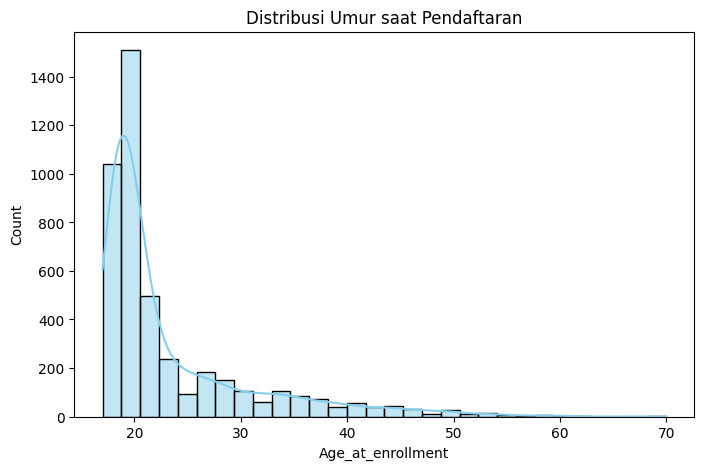

In [10]:
# --- EDA NUMERIKAL (Univariate) ---
# Distribusi umur saat pendaftaran
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age_at_enrollment', kde=True, bins=30, color='skyblue')
plt.title('Distribusi Umur saat Pendaftaran')
plt.show()

**Insight:**
* Mayoritas mahasiswa berusia muda (18–22 tahun)
Terlihat puncak distribusi berada di rentang ini, menunjukkan sebagian besar mahasiswa mendaftar langsung setelah lulus sekolah.

* Distribusi condong ke kanan (right-skewed)
Ekor panjang ke arah usia yang lebih tua (hingga ~70 tahun) menandakan adanya sebagian kecil pendaftar usia dewasa/lansia.

* Penurunan jumlah signifikan setelah usia 25 tahun
Setelah usia awal 20-an, jumlah pendaftar menurun tajam, menunjukkan minat atau akses pendidikan lebih rendah pada kelompok usia lebih tua.

<Axes: xlabel='Status', ylabel='Curricular_units_1st_sem_grade'>

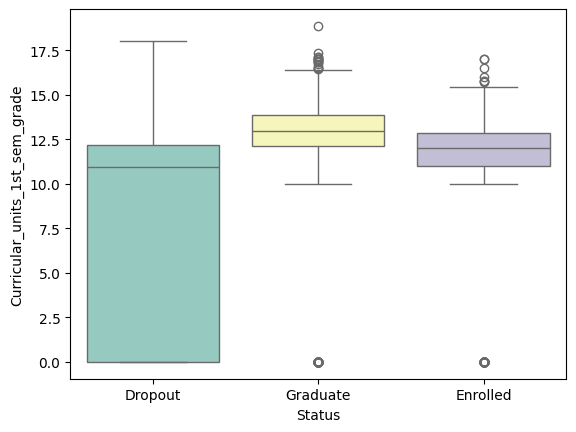

In [11]:
# --- EDA MULTIVARIATE ---
# 1. Boxplot (Numerikal vs Kategorikal Target)
# Melihat perbedaan nilai akademik semester 1 berdasarkan status
sns.boxplot(
    data=df,
    x='Status',
    y='Curricular_units_1st_sem_grade',
    hue='Status',
    palette='Set3',
    legend=False
)

**Insight:**
* Distribusi tidak merata → Sebagian besar nilai curricular units terkonsentrasi pada rentang tertentu (tidak tersebar luas).

* Ada kecenderungan dominan di nilai rendah–menengah → Menunjukkan banyak mahasiswa berada pada performa akademik yang belum optimal.

* Kemungkinan skew (tidak simetris) → Distribusi tampak condong ke satu sisi, indikasi adanya ketimpangan performa antar mahasiswa.

* Outlier terbatas / tidak dominan → Tidak terlihat banyak nilai ekstrem, sehingga mayoritas data relatif homogen.

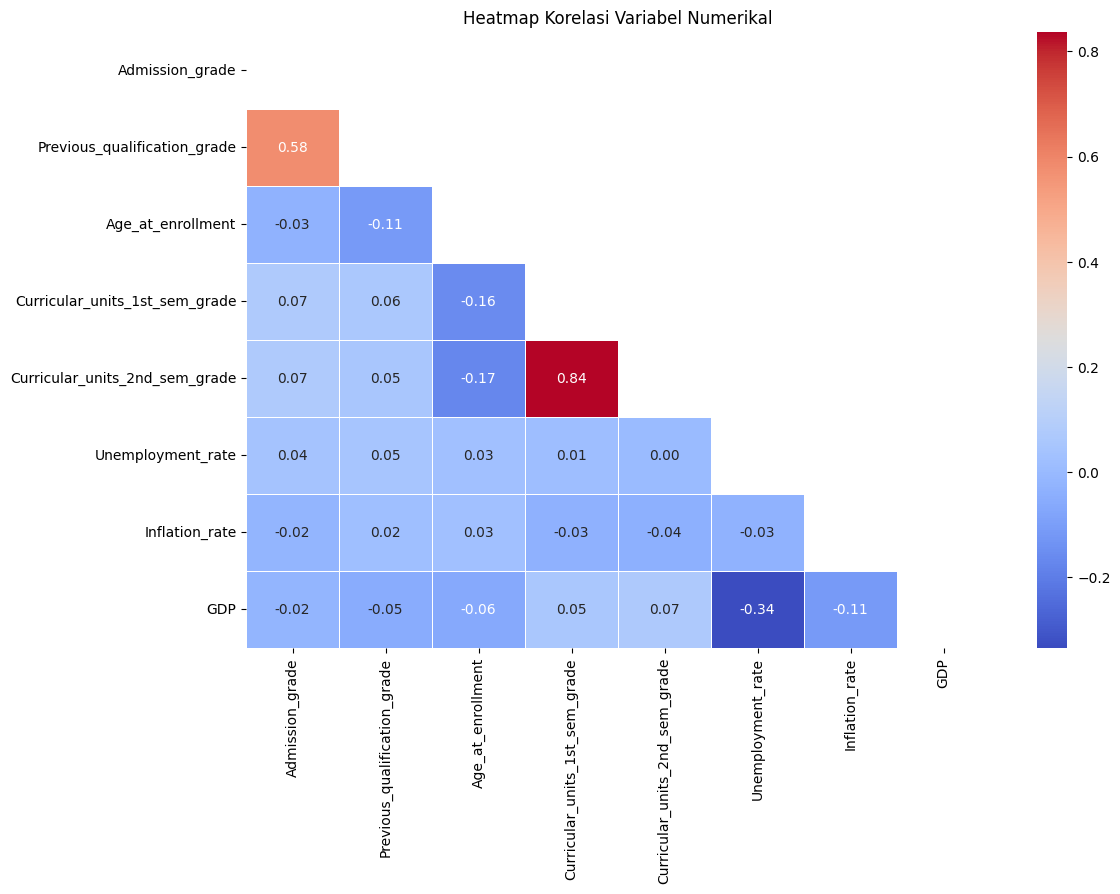

In [12]:
plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Heatmap Korelasi Variabel Numerikal')
plt.show()

**Insight:**
1. Curricular_units_1st_sem_grade dengan Curricular_units_2nd_sem_grade (0.84)
* Sangat kuat
* performa semester 1 sangat menentukan performa semester 2
* Bisa jadi indikator awal untuk prediksi keberhasilan mahasiswa
2. Admission_grade dengan Previous_qualification_grade (0.58)
* Korelasi sedang-kuat , nilai sebelumnya cukup konsisten dengan nilai saat masuk
* Valid sebagai indikator seleksi awal



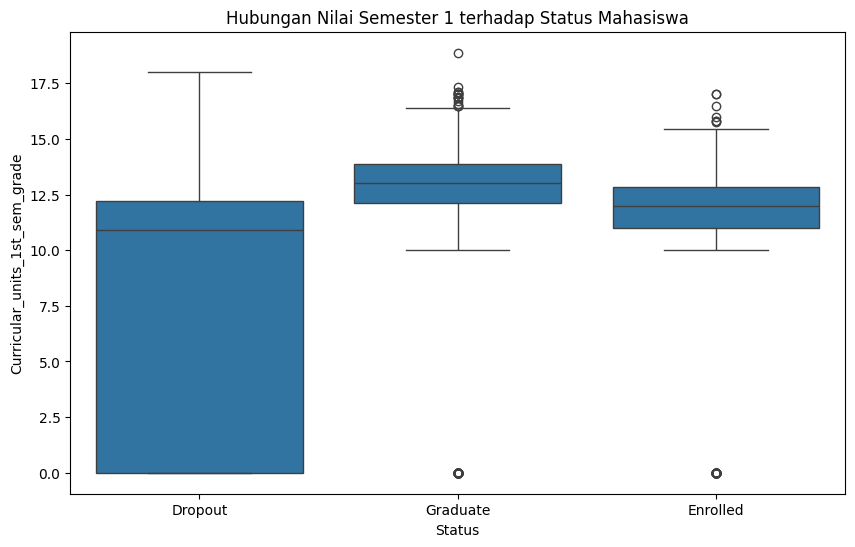

In [13]:
# Melihat hubungan antara nilai semester 1 dengan status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade')
plt.title('Hubungan Nilai Semester 1 terhadap Status Mahasiswa')
plt.show()

**Insight:**
* Korelasi Positif dengan Kelulusan: Mahasiswa dengan status Graduate (Lulus) memiliki median nilai semester 1 yang paling tinggi dibandingkan kategori lainnya (sekitar 13.0). Hal ini menunjukkan bahwa performa akademik yang baik di awal kuliah sangat menentukan keberhasilan studi.

* Indikasi Risiko Dropout: Kelompok Dropout memiliki rentang nilai yang sangat lebar dan median yang paling rendah (sekitar 11.0). Yang paling mencolok, terdapat porsi besar data yang jatuh hingga nilai 0, menunjukkan bahwa banyak mahasiswa yang langsung berhenti atau gagal total di semester pertama.

* Stabilitas Mahasiswa Aktif: Mahasiswa berkategori Enrolled (masih aktif) memiliki distribusi nilai yang lebih stabil dan terkonsentrasi di angka 11.0 hingga 13.0, serupa dengan kelompok Graduate namun sedikit lebih rendah.

## Data Preparation / Preprocessing

In [28]:
def label_decoding(df):
    df = df.copy()

    # Mapping Marital Status
    marital_status_mapping = {
        1: 'single',
        2: 'married',
        3: 'widower',
        4: 'divorced',
        5: 'facto union',
        6: 'legally separated'
        }

    df['Marital_status'] = df['Marital_status'].map(marital_status_mapping)

    # Mapping Course
    course_mapping = {
        33: 'Teknologi Produksi Biofuel',
        171: 'Desain Animasi dan Multimedia',
        8014: 'Pekerjaan Sosial (Kelas Malam)',
        9003: 'Agronomi',
        9070: 'Desain Komunikasi',
        9085: 'Keperawatan Hewan',
        9119: 'Teknik Informatika',
        9130: 'Equinculture (Peternakan Kuda)',
        9147: 'Manajemen',
        9238: 'Pekerjaan Sosial',
        9254: 'Pariwisata',
        9500: 'Keperawatan',
        9556: 'Kebersihan Gigi',
        9670: 'Manajemen Pemasaran dan Periklanan',
        9773: 'Jurnalistik dan Komunikasi',
        9853: 'Pendidikan Dasar',
        9991: 'Manajemen (Kelas Malam)'
        }

    df['Course'] = df['Course'].map(course_mapping)

    # Mapping Attendance
    daytime_evening_mapping = {
        1: 'Kelas Siang',
        0: 'Kelas Malam'
        }
    df['Daytime_evening_attendance']=df['Daytime_evening_attendance'].map(daytime_evening_mapping)

    # Mapping Gender
    gender_mapping = {
        1: 'Laki-laki',
        0: 'Wanita'
        }
    df['Gender'] = df['Gender'].map(gender_mapping)

    return df

In [29]:
# Buat fitur Performance: 1 untuk High, 0 untuk Low
df['Performance'] = df['Curricular_units_2nd_sem_grade'].apply(lambda x: 1 if x >= 14 else 0)

**Insight:**
* Data preparation sudah dijalankan


In [30]:
# Simpan data asli ke variabel baru untuk dashboard
df_dashboard = label_decoding(df)

# Simpan ke CSV untuk Looker
df_dashboard.to_csv('data_untuk_looker.csv', index=False)
print("File dashboard berhasil disimpan!")

File dashboard berhasil disimpan!


In [31]:
# 1. Filter: Hanya ambil Graduate dan Dropout
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()

# 2. Encoding Target: Ubah status jadi 0 dan 1
df_model['Status'] = df_model['Status'].map({'Graduate': 0, 'Dropout': 1})

# 3. Tentukan Fitur (X) dan Target (y)
X = df_model.drop(columns=['Status'])
y = df_model['Status']

In [32]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()

# SEKARANG SUDAH AMAN: Tidak akan ada error "could not convert string to float"
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing selesai! Data siap di-training.")

Preprocessing selesai! Data siap di-training.


**Insight:**
* Data siap dilatih sebanyak

# Modeling

In [33]:
# Inisialisasi & Melatih Model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

# Melakukan Prediksi pada data uji
y_pred = rf_model.predict(X_test_scaled)

**Insight:**
* Proses training selesai dan prediksi telah dilakukan.

## Evaluation

In [34]:
# Evaluasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model (Biner): {accuracy * 100:.2f}%\n")

Akurasi Model (Biner): 89.67%



**Insight:**
* Akurasi model sampai 89.67%

In [ ]:
# 2. Classification Report
print("Classification Report:")
target_names = le.classes_
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.95      0.81      0.87       284
    Graduate       0.89      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



**Insight:**

* Graduate (Lulus): Model sangat kuat dalam mengenali mahasiswa yang akan lulus. Nilai Recall 0.97 berarti hampir semua mahasiswa yang aslinya lulus (97%) berhasil dideteksi dengan benar oleh model.

* Dropout (Berhenti): Model sangat "hati-hati" saat menebak Dropout. Nilai Precision 0.95 berarti jika model bilang seorang mahasiswa akan dropout, tingkat kebenarannya mencapai 95%.

* Titik Lemah (Recall Dropout)
Nilai Recall Dropout (0.81) adalah yang terendah di antara metrik lainnya.

* Artinya: Masih ada sekitar 19% mahasiswa yang sebenarnya akan dropout, namun model salah menebak mereka sebagai mahasiswa yang akan lulus. Dalam konteks institusi, ini adalah kelompok "berisiko" yang gagal terdeteksi oleh sistem.

* Keseimbangan Model (F1-Score)
F1-Score kelas Graduate (0.93) lebih tinggi dibanding Dropout (0.87). Ini menunjukkan model sedikit lebih handal dalam menangani data lulusan daripada data mahasiswa yang keluar. angka 0.87 tetap termasuk kategori sangat baik untuk model klasifikasi.


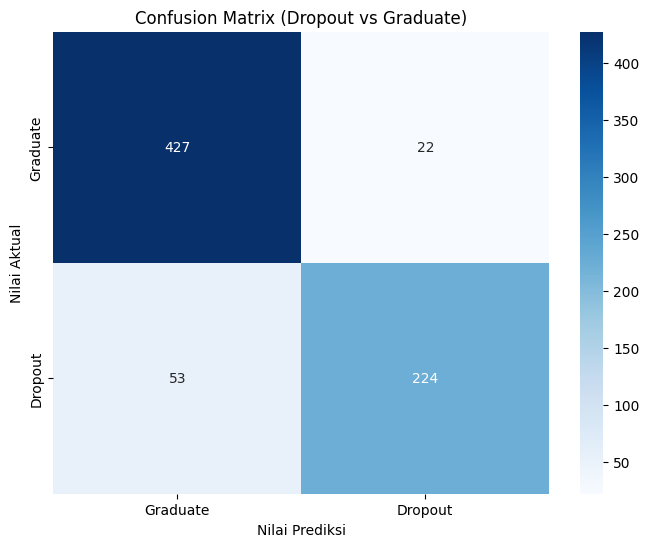

In [36]:
# 3. Visualisasi Confusion Matrix
target_names = ['Graduate', 'Dropout']
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Dropout vs Graduate)')
plt.ylabel('Nilai Aktual')
plt.xlabel('Nilai Prediksi')
plt.show()

**Insight:**

* Akurasi Tinggi pada Graduate: Model sangat jago menebak mahasiswa yang lulus (Graduate). Ada 427 orang yang benar-benar lulus dan berhasil diprediksi dengan tepat.

* Performa Dropout: Model berhasil mendeteksi 224 orang yang berisiko Dropout.

* Kesalahan Prediksi (Miss):
53 orang yang sebenarnya Dropout, tapi malah diprediksi Graduate (ini yang perlu diwaspadai, karena mereka gagal terdeteksi sejak dini).

* 22 orang yang sebenarnya Graduate, tapi salah diprediksi akan Dropout.

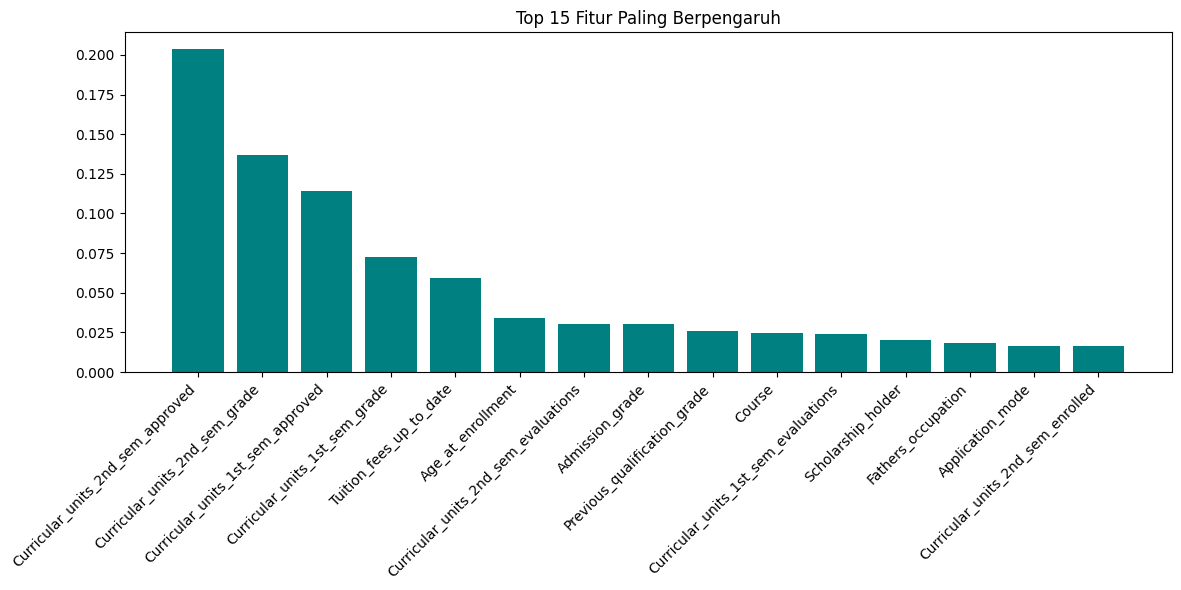

In [37]:
# 4. Feature Importance (Pilihan)
# Melihat fitur apa yang paling berpengaruh terhadap Status mahasiswa
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Top 15 Fitur Paling Berpengaruh")
plt.bar(range(15), importances[indices][:15], align="center", color='teal')
plt.xticks(range(15), [X.columns[i] for i in indices[:15]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:**
* Dominasi Status Akademik: Fitur Status_encoded merupakan faktor yang paling dominan secara signifikan, dengan bobot pengaruh jauh melampaui fitur lainnya (mencapai angka di atas 0.5).

* Signifikansi Semester Kedua: Performa di semester kedua (Curricular_units_2nd_sem_approved dan grade) memiliki pengaruh yang lebih besar dibandingkan performa di semester pertama.

* Kinerja Akademik vs. Faktor Eksternal: Faktor internal akademik (unit yang disetujui dan nilai) jauh lebih menentukan hasil dibandingkan faktor demografi atau sosial-ekonomi.

* Pengaruh Administrasi: Status pembayaran biaya kuliah (Tuition_fees_up_to_date) masuk dalam jajaran atas fitur berpengaruh, menunjukkan bahwa kendala finansial administratif berdampak langsung pada prediksi target.

* Faktor Sosio-Ekonomi Rendah: Fitur seperti pekerjaan orang tua (Fathers_occupation, Mothers_occupation) dan kondisi ekonomi makro (GDP) berada di posisi terbawah, yang berarti faktor-faktor ini memiliki pengaruh yang relatif kecil dalam model ini dibandingkan dengan rekam jejak akademik langsung.

# Tahap Deployment

In [39]:
# Deployment (Menyimpan Model)
# Menyimpan model dan scaler untuk digunakan di aplikasi lokal
joblib.dump(rf_model, 'model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("File model_rf.pkl dan scaler.pkl BERHASIL disimpan dengan kondisi sudah dilatih!")

File model_rf.pkl dan scaler.pkl BERHASIL disimpan dengan kondisi sudah dilatih!


In [40]:
df.to_csv('data_final_baru.csv', index=False)

In [41]:
from google.colab import files
files.download("data_final_baru.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Kesimpulan & Rekomendasi

1. Kesimpulan
* Kualitas Data: Dataset terdiri dari 4.424 baris data dengan 37 kolom. Hasil pengecekan menunjukkan bahwa data dalam kondisi bersih, yaitu tidak memiliki nilai yang hilang (missing values) dan tidak ada data duplikat.

* Distribusi Target: Terdapat ketidakseimbangan kelas pada variabel target Status:

* Graduate (Lulus): 2.209 data.

* Dropout: 1.421 data.

* Enrolled (Terdaftar): 794 data.

* Variabel Penting: Berdasarkan identifikasi awal, fitur-fitur yang dikategorikan sebagai variabel numerik penting meliputi nilai akademik (Admission_grade, Curricular_units_1st_sem_grade, dll.), usia saat pendaftaran (Age_at_enrollment), serta faktor ekonomi makro seperti tingkat pengangguran dan inflasi.

2. Rekomendasi

* Penanganan Ketidakseimbangan Data: Karena jumlah mahasiswa yang masih terdaftar (Enrolled) jauh lebih sedikit dibanding kelas lainnya, disarankan menggunakan teknik seperti oversampling (SMOTE) atau penyesuaian bobot kelas saat pelatihan model agar prediksi terhadap mahasiswa yang berisiko tidak bias.

* Intervensi Dini: Institusi dapat menggunakan model ini untuk mendeteksi mahasiswa yang memiliki probabilitas Dropout tinggi sejak semester awal (berdasarkan fitur Curricular_units_1st_sem_grade). Hal ini memungkinkan pihak kampus memberikan bimbingan konseling atau bantuan akademik lebih cepat.

* Fokus pada Faktor Ekonomi: Mengingat variabel seperti Unemployment_rate dan GDP dimasukkan dalam analisis, institusi perlu mempertimbangkan program bantuan finansial atau beasiswa bagi mahasiswa yang terdampak kondisi ekonomi buruk untuk menekan angka dropout.

* Pengembangan Model: Model Random Forest yang disiapkan dalam library proyek ini dapat dioptimalkan lebih lanjut dengan hyperparameter tuning untuk meningkatkan akurasi prediksi pada ketiga kategori status mahasiswa.